# Faster R-CNN Training and Evaluation

## 1. Imports

In [1]:
from pathlib import Path
import copy
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.transforms import functional as F
from torchvision.models.detection import (
    fasterrcnn_mobilenet_v3_large_320_fpn,
    FasterRCNN_MobileNet_V3_Large_320_FPN_Weights,
)


# Use validation mAP for model selection; keep the test set held out.
from torchmetrics.detection import MeanAveragePrecision
from torchvision.models.detection.faster_rcnn import (
    FastRCNNPredictor,
)

## 2. Training Environment

In [30]:
print(f"PyTorch version:     {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

cuda_available = torch.cuda.is_available()

print(f"CUDA available:      {cuda_available}")

if not cuda_available:
    raise RuntimeError(
        "CUDA is not available. "
        "Check the PyTorch and NVIDIA setup before training."
    )

print(
    f"GPU: "
    f"{torch.cuda.get_device_name(0)}"
)

DEVICE = torch.device("cuda")

PyTorch version:     2.11.0+cu128
TorchVision version: 0.26.0+cu128
CUDA available:      True
GPU: NVIDIA GeForce RTX 4060


## 3. Paths

In [31]:
PROJECT_ROOT = Path.cwd().resolve()

# Handle running from the project root or Notebooks folder.
if not (PROJECT_ROOT / "dataset_split").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASET_ROOT = PROJECT_ROOT / "dataset_split"

RCNN_RUNS = PROJECT_ROOT / "runs" / "faster_rcnn"

RCNN_RUNS.mkdir(
    parents=True,
    exist_ok=True,
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset root: {DATASET_ROOT}")
print(f"R-CNN runs:   {RCNN_RUNS}")

Project root: C:\Users\wjohn\Desktop\dobot-thesis
Dataset root: C:\Users\wjohn\Desktop\dobot-thesis\dataset_split
R-CNN runs:   C:\Users\wjohn\Desktop\dobot-thesis\runs\faster_rcnn


## 4. Dataset Check

In [32]:
required_paths = [
    DATASET_ROOT / "images" / "train",
    DATASET_ROOT / "images" / "val",
    DATASET_ROOT / "images" / "test",
    DATASET_ROOT / "labels" / "train",
    DATASET_ROOT / "labels" / "val",
    DATASET_ROOT / "labels" / "test",
]

for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(
            f"Missing dataset directory: {path}"
        )

print("All required dataset folders were found.")

All required dataset folders were found.


## 5. YOLO to Faster R-CNN Labels

YOLO boxes are converted from normalized centre/size format to pixel `x1, y1, x2, y2`. Class IDs are shifted by +1 because Faster R-CNN uses class 0 for background.

In [33]:
def read_yolo_label(
        label_path,
        image_width,
        image_height,
):
    """
    Read one YOLO label file and convert it to the
    format required by Faster R-CNN.
    """

    boxes = []
    labels = []

    # Empty label files represent empty workspace images.
    if not label_path.exists():
        raise FileNotFoundError(
            f"Missing annotation file: {label_path}"
        )

    lines = label_path.read_text(
        encoding="utf-8"
    ).strip().splitlines()

    for line in lines:
        if not line.strip():
            continue

        parts = line.split()

        # YOLO labels use class ID plus normalized centre and size.
        class_id = int(parts[0])

        x_center = float(parts[1])
        y_center = float(parts[2])
        box_width = float(parts[3])
        box_height = float(parts[4])

        # Convert normalized YOLO boxes back to pixels.
        x_center *= image_width
        y_center *= image_height
        box_width *= image_width
        box_height *= image_height

        x1 = x_center - box_width / 2.0
        y1 = y_center - box_height / 2.0
        x2 = x_center + box_width / 2.0
        y2 = y_center + box_height / 2.0

        boxes.append([
            x1,
            y1,
            x2,
            y2,
        ])

        # Shift labels by +1 because class 0 is background.
        labels.append(
            class_id + 1
        )

    return boxes, labels

## 6. Dataset

In [34]:
class BlockDetectionDataset(Dataset):
    """Dataset for the coloured block detection task."""

    def __init__(
            self,
            dataset_root,
            split,
            horizontal_flip=False,
    ):
        self.image_root = (
                dataset_root
                / "images"
                / split
        )

        self.label_root = (
                dataset_root
                / "labels"
                / split
        )

        self.horizontal_flip = horizontal_flip

        self.image_paths = sorted(
            list(
                self.image_root.rglob("*.jpg")
            )
            + list(
                self.image_root.rglob("*.jpeg")
            )
            + list(
                self.image_root.rglob("*.png")
            )
        )

    def __len__(self):
        """Return the number of images in the dataset."""
        return len(self.image_paths)

    def __getitem__(self, index):
        """Load one image and its Faster R-CNN target."""

        image_path = self.image_paths[index]

        image = Image.open(
            image_path
        ).convert("RGB")

        image_width, image_height = image.size

        # Keep the nested folder structure when matching labels.
        relative_path = image_path.relative_to(
            self.image_root
        )

        label_path = (
                self.label_root
                / relative_path
        ).with_suffix(".txt")

        boxes, labels = read_yolo_label(
            label_path=label_path,
            image_width=image_width,
            image_height=image_height,
        )

        boxes = torch.as_tensor(
            boxes,
            dtype=torch.float32,
        ).reshape(-1, 4)

        labels = torch.as_tensor(
            labels,
            dtype=torch.int64,
        )

        image = F.pil_to_tensor(
            image
        ).float() / 255.0

        # Flip the image and boxes together.
        if (
                self.horizontal_flip
                and torch.rand(1).item() < 0.5
        ):
            image = F.hflip(
                image
            )

            if len(boxes) > 0:
                old_x1 = boxes[:, 0].clone()
                old_x2 = boxes[:, 2].clone()

                boxes[:, 0] = (
                        image_width - old_x2
                )

                boxes[:, 2] = (
                        image_width - old_x1
                )

        if len(boxes) > 0:
            area = (
                    (boxes[:, 2] - boxes[:, 0])
                    * (boxes[:, 3] - boxes[:, 1])
            )
        else:
            # Empty workspace images have no boxes.
            area = torch.zeros(
                (0,),
                dtype=torch.float32,
            )

        iscrowd = torch.zeros(
            (len(boxes),),
            dtype=torch.int64,
        )

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": index,
            "area": area,
            "iscrowd": iscrowd,
        }

        return image, target

## 7. Train, Validation and Test Sets

In [35]:
# Apply augmentation to the training set only.
train_dataset = BlockDetectionDataset(
    DATASET_ROOT,
    "train",
    horizontal_flip=True,
)

val_dataset = BlockDetectionDataset(
    DATASET_ROOT,
    "val",
    horizontal_flip=False,
)

test_dataset = BlockDetectionDataset(
    DATASET_ROOT,
    "test",
    horizontal_flip=False,
)

print(
    f"Training images:   "
    f"{len(train_dataset)}"
)

print(
    f"Validation images: "
    f"{len(val_dataset)}"
)

print(
    f"Test images:       "
    f"{len(test_dataset)}"
)

print(
    "Training horizontal flip: enabled"
)

print(
    "Validation/test augmentation: disabled"
)

Training images:   259
Validation images: 74
Test images:       37
Training horizontal flip: enabled
Validation/test augmentation: disabled


## 8. Annotation Check

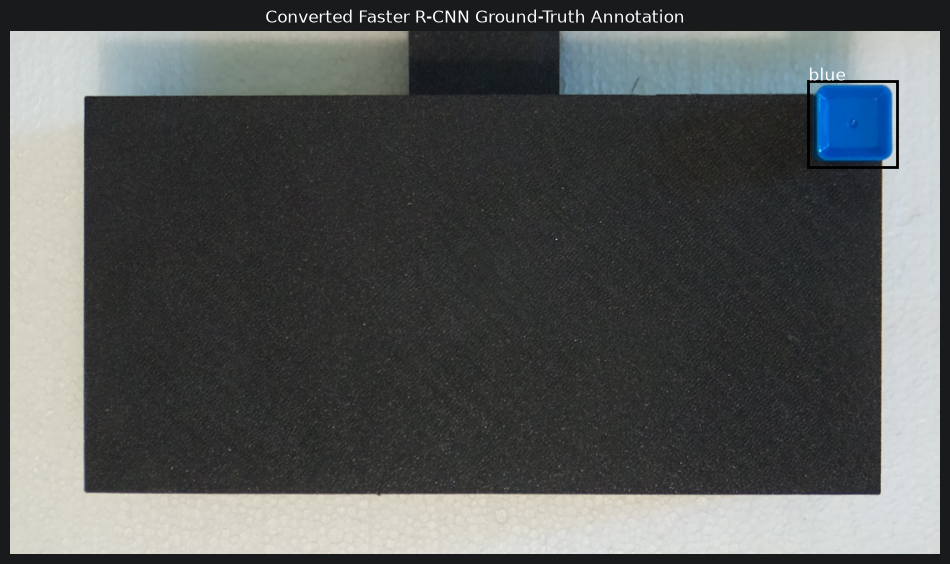

In [36]:
image, target = train_dataset[0]

# Convert CHW to HWC for Matplotlib.
display_image = image.permute(
    1,
    2,
    0,
).numpy()

class_names = {
    1: "red",
    2: "blue",
    3: "yellow",
    4: "green",
}

fig, ax = plt.subplots(
    figsize=(12, 7)
)

ax.imshow(
    display_image
)

for box, label in zip(
        target["boxes"],
        target["labels"],
):
    x1, y1, x2, y2 = box.tolist()

    rectangle = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        linewidth=2,
    )

    ax.add_patch(
        rectangle
    )

    ax.text(
        x1,
        y1,
        class_names[int(label)],
        fontsize=12,
    )

ax.set_title(
    "Converted Faster R-CNN Ground-Truth Annotation"
)

ax.axis("off")

plt.show()

## 9. Data Loaders

In [37]:
def collate_fn(batch):
    """Keep images and detection targets as separate lists."""
    return tuple(zip(*batch))


# Use a small batch size for Faster R-CNN GPU memory.
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn,
)

print("Data loaders created.")

Data loaders created.


## 10. Faster R-CNN MobileNetV3-Large 320 FPN

COCO-pretrained weights are fine-tuned for the four block classes.

In [38]:
# Four block classes plus background.
NUM_CLASSES = 5

weights = (
    FasterRCNN_MobileNet_V3_Large_320_FPN_Weights.DEFAULT
)

model = fasterrcnn_mobilenet_v3_large_320_fpn(
    weights=weights,
)

in_features = (
    model.roi_heads.box_predictor
    .cls_score
    .in_features
)

# Replace the COCO head for this dataset.
model.roi_heads.box_predictor = (
    FastRCNNPredictor(
        in_features,
        NUM_CLASSES,
    )
)

model = model.to(DEVICE)

print("Faster R-CNN model loaded.")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Device: {DEVICE}")

Faster R-CNN model loaded.
Number of classes: 5
Device: cuda


## 11. Training Configuration

In [39]:
MAX_EPOCHS = 30

# Stop if validation mAP stops improving.
EARLY_STOPPING_PATIENCE = 8

MIN_IMPROVEMENT = 0.0001

BEST_MODEL_PATH = (
        RCNN_RUNS
        / "faster_rcnn_mobilenet_v3_320_best.pth"
)

HISTORY_PATH = (
        RCNN_RUNS
        / "faster_rcnn_training_history.csv"
)

np.random.seed(42)
# Use a fixed seed for reproducibility.
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

trainable_parameters = [
    parameter
    for parameter in model.parameters()
    if parameter.requires_grad
]

optimizer = torch.optim.SGD(
    trainable_parameters,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0001,
)

lr_scheduler = (
    # Reduce the learning rate when validation mAP stalls.
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.2,
        patience=3,
        min_lr=1e-6,
    )
)

print(f"Maximum epochs: {MAX_EPOCHS}")
print(
    f"Early stopping patience: "
    f"{EARLY_STOPPING_PATIENCE}"
)
print(f"Best model path: {BEST_MODEL_PATH}")

Maximum epochs: 30
Early stopping patience: 8
Best model path: C:\Users\wjohn\Desktop\dobot-thesis\runs\faster_rcnn\faster_rcnn_mobilenet_v3_320_best.pth


## 12. Training Function

In [40]:
def train_one_epoch(
        model,
        data_loader,
        optimizer,
        device,
):
    """Train Faster R-CNN for one complete epoch."""

    model.train()

    total_loss = 0.0

    for batch_index, (
            images,
            targets,
    ) in enumerate(data_loader):

        images = [
            image.to(device)
            for image in images
        ]

        gpu_targets = []

        for target in targets:
            gpu_target = {}

            for key, value in target.items():
                if torch.is_tensor(value):
                    gpu_target[key] = value.to(
                        device
                    )
                else:
                    gpu_target[key] = value

            gpu_targets.append(
                gpu_target
            )

        # Faster R-CNN returns several loss terms.
        loss_dict = model(
            images,
            gpu_targets,
        )

        # Sum the loss terms for training.
        losses = sum(
            loss
            for loss in loss_dict.values()
        )

        optimizer.zero_grad()

        losses.backward()

        optimizer.step()

        total_loss += losses.item()

        if (
                batch_index == 0
                or (batch_index + 1) % 10 == 0
                or batch_index + 1 == len(data_loader)
        ):
            print(
                f"Batch "
                f"{batch_index + 1}/"
                f"{len(data_loader)} "
                f"loss={losses.item():.4f}"
            )

    mean_loss = (
            total_loss
            / len(data_loader)
    )

    return mean_loss

## 13. Validation Function

In [41]:
@torch.no_grad()
def evaluate_detection_map(
        model,
        data_loader,
        device,
):
    """Evaluate Faster R-CNN using object-detection mAP."""

    model.eval()

    metric = MeanAveragePrecision(
        box_format="xyxy",
        iou_type="bbox",
        class_metrics=True,
    )

    for images, targets in data_loader:

        gpu_images = [
            image.to(device)
            for image in images
        ]

        outputs = model(
            gpu_images
        )

        metric_predictions = []
        metric_targets = []

        for output, target in zip(
                outputs,
                targets,
        ):
            metric_predictions.append({
                "boxes": (
                    output["boxes"]
                    .detach()
                    .cpu()
                ),
                "scores": (
                    output["scores"]
                    .detach()
                    .cpu()
                ),
                # Shift class IDs from 1-4 back to dataset IDs 0-3.
                "labels": (
                        output["labels"]
                        .detach()
                        .cpu()
                        - 1
                ),
            })

            metric_targets.append({
                "boxes": (
                    target["boxes"]
                    .detach()
                    .cpu()
                ),
                "labels": (
                        target["labels"]
                        .detach()
                        .cpu()
                        - 1
                ),
            })

        metric.update(
            metric_predictions,
            metric_targets,
        )

    results = metric.compute()

    return results

## 14. Train Faster R-CNN

The best checkpoint is selected using validation mAP@0.50:0.95. The test set stays held out.

In [42]:
training_history = []

best_val_map = -1.0

best_epoch = 0

# Track epochs without validation improvement.
epochs_without_improvement = 0

training_start = time.perf_counter()

for epoch in range(
        1,
        MAX_EPOCHS + 1,
):

    print()
    print(
        f"===== EPOCH "
        f"{epoch}/{MAX_EPOCHS} ====="
    )

    train_loss = train_one_epoch(
        model=model,
        data_loader=train_loader,
        optimizer=optimizer,
        device=DEVICE,
    )

    print()
    print(
        f"Mean training loss: "
        f"{train_loss:.4f}"
    )

    print(
        "Evaluating validation set..."
    )

    val_metrics = evaluate_detection_map(
        model=model,
        data_loader=val_loader,
        device=DEVICE,
    )

    val_map = float(
        val_metrics["map"]
    )

    val_map50 = float(
        val_metrics["map_50"]
    )

    val_map75 = float(
        val_metrics["map_75"]
    )

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    print(
        f"Validation mAP@0.50:      "
        f"{val_map50:.4f}"
    )

    print(
        f"Validation mAP@0.75:      "
        f"{val_map75:.4f}"
    )

    print(
        f"Validation mAP@0.50:0.95: "
        f"{val_map:.4f}"
    )

    print(
        f"Learning rate:             "
        f"{current_lr:.6f}"
    )

    training_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_map50": val_map50,
        "val_map75": val_map75,
        "val_map50_95": val_map,
        "learning_rate": current_lr,
    })

    # Save the best checkpoint by validation mAP@0.50:0.95.
    if (
            val_map
            > best_val_map + MIN_IMPROVEMENT
    ):

        best_val_map = val_map
        best_epoch = epoch

        epochs_without_improvement = 0

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH,
        )

        print(
            "New best model saved."
        )

    else:
        epochs_without_improvement += 1

        print(
            "No validation improvement. "
            f"Count: "
            f"{epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )

    # Update the scheduler using validation mAP.
    lr_scheduler.step(
        val_map
    )

    if (
            epochs_without_improvement
            >= EARLY_STOPPING_PATIENCE
    ):
        print()
        print(
            "Early stopping triggered."
        )

        break

training_time_seconds = (
        time.perf_counter()
        - training_start
)

print()
print("TRAINING FINISHED")
print(
    f"Best epoch: "
    f"{best_epoch}"
)
print(
    f"Best validation mAP@0.50:0.95: "
    f"{best_val_map:.4f}"
)
print(
    f"Training time: "
    f"{training_time_seconds / 60.0:.2f} minutes"
)
print(
    f"Best model: "
    f"{BEST_MODEL_PATH}"
)


===== EPOCH 1/30 =====
Batch 1/65 loss=2.3989
Batch 10/65 loss=3.0230
Batch 20/65 loss=2.0915
Batch 30/65 loss=1.7269
Batch 40/65 loss=0.9281
Batch 50/65 loss=1.4598
Batch 60/65 loss=0.9253
Batch 65/65 loss=1.3451

Mean training loss: 1.5309
Evaluating validation set...
Validation mAP@0.50:      0.9139
Validation mAP@0.75:      0.6087
Validation mAP@0.50:0.95: 0.5467
Learning rate:             0.005000
New best model saved.

===== EPOCH 2/30 =====
Batch 1/65 loss=1.1966
Batch 10/65 loss=0.5784
Batch 20/65 loss=0.6074
Batch 30/65 loss=0.7009
Batch 40/65 loss=0.6819
Batch 50/65 loss=0.4649
Batch 60/65 loss=0.3752
Batch 65/65 loss=0.2619

Mean training loss: 0.6465
Evaluating validation set...
Validation mAP@0.50:      1.0000
Validation mAP@0.75:      0.9822
Validation mAP@0.50:0.95: 0.7432
Learning rate:             0.005000
New best model saved.

===== EPOCH 3/30 =====
Batch 1/65 loss=0.4996
Batch 10/65 loss=0.2896
Batch 20/65 loss=0.7916
Batch 30/65 loss=0.4252
Batch 40/65 loss=0.7231

## 15. Training History

In [43]:
history_df = pd.DataFrame(
    training_history
)

history_df.to_csv(
    HISTORY_PATH,
    index=False,
)

print(
    f"Training history saved to: "
    f"{HISTORY_PATH}"
)

display(
    history_df
)

Training history saved to: C:\Users\wjohn\Desktop\dobot-thesis\runs\faster_rcnn\faster_rcnn_training_history.csv


,epoch,train_loss,val_map50,val_map75,val_map50_95,learning_rate
0,1,1.530941,0.913878,0.608707,0.546668,0.00500
1,2,0.646532,1.000000,0.982161,0.743249,0.00500
2,3,0.544842,1.000000,1.000000,0.806677,0.00500
3,4,0.500042,1.000000,1.000000,0.850680,0.00500
4,5,0.363116,1.000000,1.000000,0.846708,0.00500
5,6,0.405140,1.000000,1.000000,0.851700,0.00500
6,7,0.351100,1.000000,1.000000,0.848095,0.00500
7,8,0.416994,1.000000,1.000000,0.881291,0.00500
8,9,0.313114,1.000000,1.000000,0.862729,0.00500
9,10,0.300286,1.000000,1.000000,0.891961,0.00500


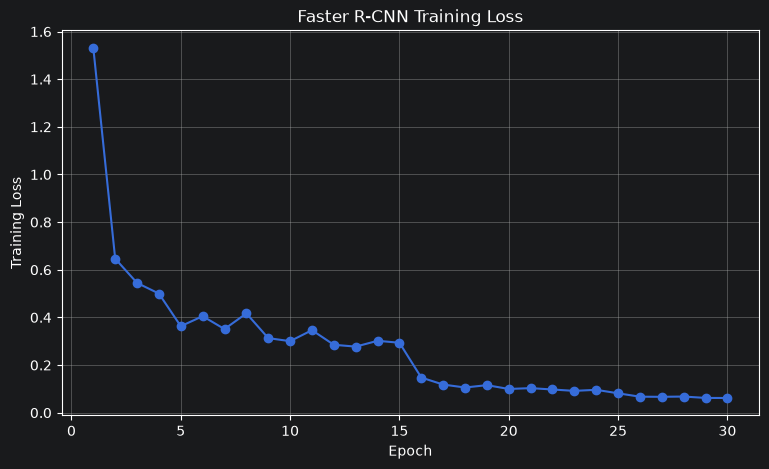

In [44]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title(
    "Faster R-CNN Training Loss"
)

plt.grid(True)

plt.show()

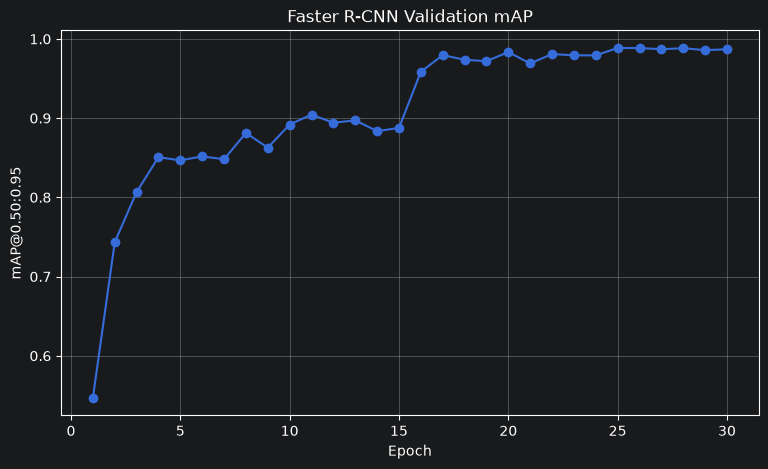

In [45]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["val_map50_95"],
    marker="o",
)

plt.xlabel("Epoch")
plt.ylabel("mAP@0.50:0.95")

plt.title(
    "Faster R-CNN Validation mAP"
)

plt.grid(True)

plt.show()

## 16. Load Best Checkpoint

In [46]:
if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Best model not found: "
        f"{BEST_MODEL_PATH}"
    )

# Load the best validation checkpoint.
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE,
    )
)

model.eval()

print(
    f"Best model loaded from: "
    f"{BEST_MODEL_PATH}"
)

print(
    f"Best epoch: "
    f"{best_epoch}"
)

print(
    f"Best validation mAP@0.50:0.95: "
    f"{best_val_map:.4f}"
)

Best model loaded from: C:\Users\wjohn\Desktop\dobot-thesis\runs\faster_rcnn\faster_rcnn_mobilenet_v3_320_best.pth
Best epoch: 25
Best validation mAP@0.50:0.95: 0.9886


## 17. Validation and Test Predictions

Validation predictions select the confidence threshold. Test predictions are used for the final evaluation.

In [47]:
@torch.no_grad()
def collect_predictions(
        model,
        data_loader,
        device,
):
    """Collect predictions and ground truth for a dataset."""

    model.eval()

    predictions = []
    targets = []

    for images, batch_targets in data_loader:

        gpu_images = [
            image.to(device)
            for image in images
        ]

        outputs = model(
            gpu_images
        )

        for output, target in zip(
                outputs,
                batch_targets,
        ):
            predictions.append({
                "boxes": (
                    output["boxes"]
                    .detach()
                    .cpu()
                ),
                "scores": (
                    output["scores"]
                    .detach()
                    .cpu()
                ),
                # Shift labels from 1-4 back to dataset IDs 0-3.
                "labels": (
                        output["labels"]
                        .detach()
                        .cpu()
                        - 1
                ),
            })

            targets.append({
                "boxes": (
                    target["boxes"]
                    .detach()
                    .cpu()
                ),
                "labels": (
                        target["labels"]
                        .detach()
                        .cpu()
                        - 1
                ),
            })

    return predictions, targets


# Collect validation and held-out test predictions.
val_predictions, val_targets = (
    collect_predictions(
        model=model,
        data_loader=val_loader,
        device=DEVICE,
    )
)

test_predictions, test_targets = (
    collect_predictions(
        model=model,
        data_loader=test_loader,
        device=DEVICE,
    )
)

print(
    f"Validation images evaluated: "
    f"{len(val_predictions)}"
)

print(
    f"Test images evaluated: "
    f"{len(test_predictions)}"
)

Validation images evaluated: 74
Test images evaluated: 37


## 18. Test mAP

In [48]:
test_map_metric = MeanAveragePrecision(
    box_format="xyxy",
    iou_type="bbox",
    class_metrics=True,
)

test_map_metric.update(
    test_predictions,
    test_targets,
)

test_map_results = (
    test_map_metric.compute()
)

test_map50 = float(
    test_map_results["map_50"]
)

test_map75 = float(
    test_map_results["map_75"]
)

test_map50_95 = float(
    test_map_results["map"]
)

test_mar100 = float(
    test_map_results["mar_100"]
)

print()
print("FASTER R-CNN TEST RESULTS")

print(
    f"mAP@0.50:      "
    f"{test_map50:.4f}"
)

print(
    f"mAP@0.75:      "
    f"{test_map75:.4f}"
)

print(
    f"mAP@0.50:0.95: "
    f"{test_map50_95:.4f}"
)

print(
    f"mAR@100:       "
    f"{test_mar100:.4f}"
)


FASTER R-CNN TEST RESULTS
-------------------------
mAP@0.50:      1.0000
mAP@0.75:      1.0000
mAP@0.50:0.95: 0.9927
mAR@100:       0.9946


## 19. Per-Class Test Results

In [49]:
class_names = {
    0: "RED",
    1: "BLUE",
    2: "YELLOW",
    3: "GREEN",
}


def calculate_class_map(
        predictions,
        targets,
        class_id,
):
    """Calculate mAP metrics for one object class."""

    class_predictions = []
    class_targets = []

    for prediction, target in zip(
            predictions,
            targets,
    ):
        pred_mask = (
                prediction["labels"]
                == class_id
        )

        target_mask = (
                target["labels"]
                == class_id
        )

        # Relabel this class as 0 for the single-class metric.
        class_predictions.append({
            "boxes": (
                prediction["boxes"][
                    pred_mask
                ]
            ),
            "scores": (
                prediction["scores"][
                    pred_mask
                ]
            ),
            "labels": torch.zeros(
                int(pred_mask.sum()),
                dtype=torch.int64,
            ),
        })

        class_targets.append({
            "boxes": (
                target["boxes"][
                    target_mask
                ]
            ),
            "labels": torch.zeros(
                int(target_mask.sum()),
                dtype=torch.int64,
            ),
        })

    metric = MeanAveragePrecision(
        box_format="xyxy",
        iou_type="bbox",
    )

    metric.update(
        class_predictions,
        class_targets,
    )

    results = metric.compute()

    return {
        "map50": float(
            results["map_50"]
        ),
        "map75": float(
            results["map_75"]
        ),
        "map50_95": float(
            results["map"]
        ),
    }


per_class_map_results = {}

for class_id, class_name in (
        class_names.items()
):
    class_result = calculate_class_map(
        predictions=test_predictions,
        targets=test_targets,
        class_id=class_id,
    )

    per_class_map_results[
        class_id
    ] = class_result

    print()
    print(class_name)

    print(
        f"mAP@0.50:      "
        f"{class_result['map50']:.4f}"
    )

    print(
        f"mAP@0.75:      "
        f"{class_result['map75']:.4f}"
    )

    print(
        f"mAP@0.50:0.95: "
        f"{class_result['map50_95']:.4f}"
    )


RED
mAP@0.50:      1.0000
mAP@0.75:      1.0000
mAP@0.50:0.95: 1.0000

BLUE
mAP@0.50:      1.0000
mAP@0.75:      1.0000
mAP@0.50:0.95: 0.9911

YELLOW
mAP@0.50:      1.0000
mAP@0.75:      1.0000
mAP@0.50:0.95: 0.9885

GREEN
mAP@0.50:      1.0000
mAP@0.75:      1.0000
mAP@0.50:0.95: 0.9911


## 20. Confidence Threshold

The confidence threshold is selected on the validation set using mean F1.

In [50]:
def build_detection_confusion_matrix(
        predictions,
        targets,
        confidence_threshold,
        iou_threshold=0.50,
):
    """
    Match predictions with ground-truth boxes and create
    an object-detection confusion matrix.
    """

    # The background row and column record false positives and misses.
    num_classes = 4
    background_id = num_classes

    confusion_matrix = np.zeros(
        (
            num_classes + 1,
            num_classes + 1,
        ),
        dtype=np.int64,
    )

    for prediction, target in zip(
            predictions,
            targets,
    ):

        keep = (
                prediction["scores"]
                >= confidence_threshold
        )

        pred_boxes = (
            prediction["boxes"][keep]
        )

        pred_scores = (
            prediction["scores"][keep]
        )

        pred_labels = (
            prediction["labels"][keep]
        )

        gt_boxes = target["boxes"]
        gt_labels = target["labels"]

        # Match higher-confidence predictions first.
        if len(pred_scores) > 0:
            order = torch.argsort(
                pred_scores,
                descending=True,
            )

            pred_boxes = pred_boxes[
                order
            ]

            pred_labels = pred_labels[
                order
            ]

        # Prevent duplicate matches to the same ground-truth box.
        matched_gt = torch.zeros(
            len(gt_boxes),
            dtype=torch.bool,
        )

        for pred_box, pred_label in zip(
                pred_boxes,
                pred_labels,
        ):

            if len(gt_boxes) == 0:
                confusion_matrix[
                    background_id,
                    int(pred_label),
                ] += 1

                continue

            ious = torchvision.ops.box_iou(
                pred_box.unsqueeze(0),
                gt_boxes,
            )[0]

            ious[
                matched_gt
            ] = -1.0

            best_iou, best_gt_index = (
                torch.max(
                    ious,
                    dim=0,
                )
            )

            if (
                    float(best_iou)
                    >= iou_threshold
            ):
                gt_label = int(
                    gt_labels[
                        best_gt_index
                    ]
                )

                confusion_matrix[
                    gt_label,
                    int(pred_label),
                ] += 1

                matched_gt[
                    best_gt_index
                ] = True

            else:
                confusion_matrix[
                    background_id,
                    int(pred_label),
                ] += 1

        # Unmatched ground truth is a missed detection.
        for gt_index, was_matched in enumerate(
                matched_gt
        ):
            if not bool(was_matched):
                confusion_matrix[
                    int(gt_labels[gt_index]),
                    background_id,
                ] += 1

    return confusion_matrix

In [51]:
def calculate_precision_recall(
        confusion_matrix,
):
    """Calculate per-class and mean precision, recall and F1."""

    class_results = []

    for class_id in range(4):
        # True positives.
        true_positive = (
            confusion_matrix[
                class_id,
                class_id,
            ]
        )

        # False positives.
        false_positive = (
                confusion_matrix[
                    :,
                    class_id,
                ].sum()
                - true_positive
        )

        # False negatives.
        false_negative = (
                confusion_matrix[
                    class_id,
                    :,
                ].sum()
                - true_positive
        )

        precision = (
            true_positive
            / (
                    true_positive
                    + false_positive
            )
            if (
                       true_positive
                       + false_positive
               ) > 0
            else 0.0
        )

        recall = (
            true_positive
            / (
                    true_positive
                    + false_negative
            )
            if (
                       true_positive
                       + false_negative
               ) > 0
            else 0.0
        )

        f1 = (
            2
            * precision
            * recall
            / (
                    precision
                    + recall
            )
            if (
                       precision
                       + recall
               ) > 0
            else 0.0
        )

        class_results.append({
            "class_id": class_id,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })

    mean_precision = np.mean([
        result["precision"]
        for result in class_results
    ])

    mean_recall = np.mean([
        result["recall"]
        for result in class_results
    ])

    mean_f1 = np.mean([
        result["f1"]
        for result in class_results
    ])

    return (
        class_results,
        mean_precision,
        mean_recall,
        mean_f1,
    )

In [52]:
confidence_thresholds = np.arange(
    0.05,
    1.00,
    0.05,
)

threshold_results = []

# Choose the threshold on validation data only.
for confidence_threshold in (
        confidence_thresholds
):
    validation_confusion = (
        build_detection_confusion_matrix(
            predictions=val_predictions,
            targets=val_targets,
            confidence_threshold=(
                confidence_threshold
            ),
            iou_threshold=0.50,
        )
    )

    (
        _,
        mean_precision,
        mean_recall,
        mean_f1,
    ) = calculate_precision_recall(
        validation_confusion
    )

    threshold_results.append({
        "threshold": (
            confidence_threshold
        ),
        "precision": mean_precision,
        "recall": mean_recall,
        "f1": mean_f1,
    })

threshold_df = pd.DataFrame(
    threshold_results
)

# Select the threshold with the highest mean F1.
best_threshold_row = (
    threshold_df.loc[
        threshold_df["f1"].idxmax()
    ]
)

BEST_CONFIDENCE_THRESHOLD = float(
    best_threshold_row["threshold"]
)

print(
    f"Selected validation confidence threshold: "
    f"{BEST_CONFIDENCE_THRESHOLD:.2f}"
)

print(
    f"Validation mean precision: "
    f"{best_threshold_row['precision']:.4f}"
)

print(
    f"Validation mean recall:    "
    f"{best_threshold_row['recall']:.4f}"
)

print(
    f"Validation mean F1:        "
    f"{best_threshold_row['f1']:.4f}"
)

Selected validation confidence threshold: 0.20
Validation mean precision: 1.0000
Validation mean recall:    1.0000
Validation mean F1:        1.0000


## 21. Test Precision, Recall and F1

In [53]:
# Apply the validation-selected threshold to the test set.
test_confusion_matrix = (
    build_detection_confusion_matrix(
        predictions=test_predictions,
        targets=test_targets,
        confidence_threshold=(
            BEST_CONFIDENCE_THRESHOLD
        ),
        iou_threshold=0.50,
    )
)

(
    test_class_pr,
    test_precision,
    test_recall,
    test_f1,
) = calculate_precision_recall(
    test_confusion_matrix
)

print()
print("FASTER R-CNN TEST PRECISION / RECALL")

print(
    f"Confidence threshold: "
    f"{BEST_CONFIDENCE_THRESHOLD:.2f}"
)

print(
    f"Precision: "
    f"{test_precision:.4f}"
)

print(
    f"Recall:    "
    f"{test_recall:.4f}"
)

print(
    f"F1:        "
    f"{test_f1:.4f}"
)

for result in test_class_pr:
    class_id = result[
        "class_id"
    ]

    print()
    print(
        class_names[
            class_id
        ]
    )

    print(
        f"Precision: "
        f"{result['precision']:.4f}"
    )

    print(
        f"Recall:    "
        f"{result['recall']:.4f}"
    )

    print(
        f"F1:        "
        f"{result['f1']:.4f}"
    )


FASTER R-CNN TEST PRECISION / RECALL
------------------------------------
Confidence threshold: 0.20
Precision: 1.0000
Recall:    1.0000
F1:        1.0000

RED
Precision: 1.0000
Recall:    1.0000
F1:        1.0000

BLUE
Precision: 1.0000
Recall:    1.0000
F1:        1.0000

YELLOW
Precision: 1.0000
Recall:    1.0000
F1:        1.0000

GREEN
Precision: 1.0000
Recall:    1.0000
F1:        1.0000


## 22. Test Confusion Matrix

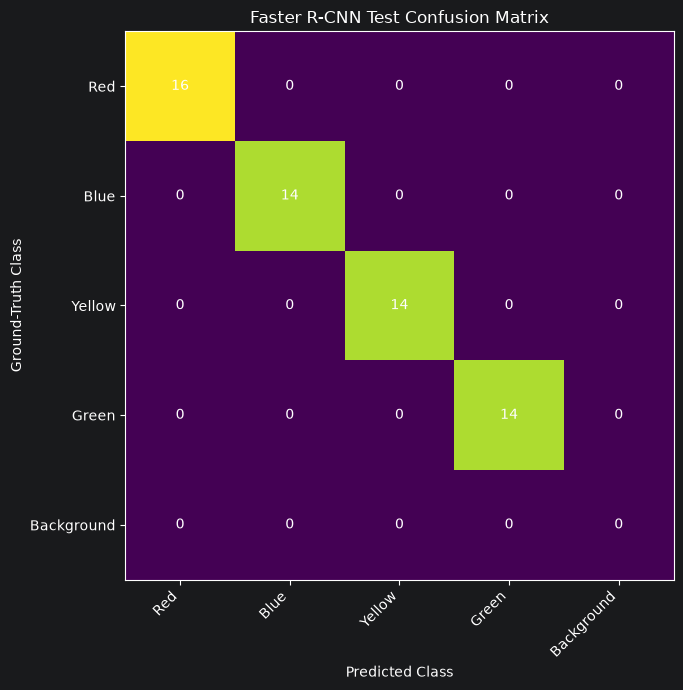

In [54]:
confusion_labels = [
    "Red",
    "Blue",
    "Yellow",
    "Green",
    "Background",
]

fig, ax = plt.subplots(
    figsize=(8, 7)
)

image = ax.imshow(
    test_confusion_matrix
)

ax.set_xticks(
    range(len(confusion_labels))
)

ax.set_yticks(
    range(len(confusion_labels))
)

ax.set_xticklabels(
    confusion_labels,
    rotation=45,
    ha="right",
)

ax.set_yticklabels(
    confusion_labels
)

ax.set_xlabel(
    "Predicted Class"
)

ax.set_ylabel(
    "Ground-Truth Class"
)

ax.set_title(
    "Faster R-CNN Test Confusion Matrix"
)

for row in range(
        test_confusion_matrix.shape[0]
):
    for column in range(
            test_confusion_matrix.shape[1]
    ):
        ax.text(
            column,
            row,
            int(
                test_confusion_matrix[
                    row,
                    column,
                ]
            ),
            ha="center",
            va="center",
        )

fig.tight_layout()

plt.show()

## 23. Final Test Summary

In [55]:
print()
print("FINAL FASTER R-CNN TEST RESULTS")
print(
    f"Precision:      "
    f"{test_precision:.4f}"
)

print(
    f"Recall:         "
    f"{test_recall:.4f}"
)

print(
    f"F1:             "
    f"{test_f1:.4f}"
)

print(
    f"mAP@0.50:       "
    f"{test_map50:.4f}"
)

print(
    f"mAP@0.75:       "
    f"{test_map75:.4f}"
)

print(
    f"mAP@0.50:0.95:  "
    f"{test_map50_95:.4f}"
)

print(
    f"Confidence:     "
    f"{BEST_CONFIDENCE_THRESHOLD:.2f}"
)


FINAL FASTER R-CNN TEST RESULTS
Precision:      1.0000
Recall:         1.0000
F1:             1.0000
mAP@0.50:       1.0000
mAP@0.75:       1.0000
mAP@0.50:0.95:  0.9927
Confidence:     0.20
